# 1-ETUDE DE POSITIONNEMENT BANCAIRE
## 1-1 Total bilan des banques

In [50]:
import matplotlib.image as mpimg

def ajouter_logo(fig):
    """Incruste le logo BGFI en haut à droite de la figure Matplotlib"""
    try:
        # On charge le logo
        logo = mpimg.imread('logo_bgfi.jfif')
        
        # On crée un nouvel axe pour le logo (position : [gauche, bas, largeur, hauteur])
        # [0.85, 0.88, 0.12, 0.12] place le logo en haut à droite
        ax_logo = fig.add_axes([0.85, 0.88, 0.12, 0.12], anchor='NE', zorder=10)
        
        ax_logo.imshow(logo)
        ax_logo.axis('off') # Cache les axes du logo
    except Exception as e:
        print(f"⚠️ Impossible d'ajouter le logo : {e}")


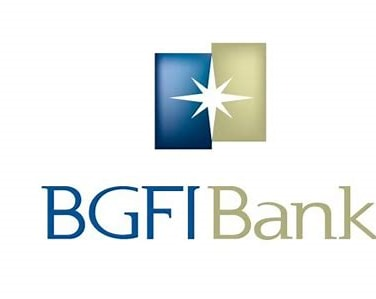

In [ ]:
import base64
from IPython.display import display, HTML


# 1. Conversion du logo en Base64 pour qu'il soit intégré au fichier
def get_base64_image(image_path):
    try:
        with open(image_path, "rb") as img_file:
            return base64.b64encode(img_file.read()).decode('utf-8')
    except:
        return ""

# Chemin de ton logo (assure-toi que le fichier est dans le même dossier)
logo_base64 = get_base64_image("logo_bgfi.jfif")
logo_html = f"data:image/jfif;base64,{logo_base64}" if logo_base64 else ""

# 2. Configuration Visuelle
C_BGFI = '#004a99'

html_intro = f"""
<div style="font-family: 'Arial', sans-serif; background-color: white; padding: 0; border: 1px solid #eee; min-height: 500px;">

    <div style="padding: 40px 0 20px 50px;">
        <h1 style="color: {C_BGFI}; font-weight: 800; font-size: 34px; margin: 0; letter-spacing: -1px;">
             STRATÉGIE BGFI BANK
        </h1>
        <p style="color: #666; font-size: 18px; margin-top: 5px;">
            Analyse comparative et dynamique de croissance (2015-2020)
        </p>
    </div>

    <div style="background-color: {C_BGFI}; padding: 20px 0; width: 100%; margin: 25px 0; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
        <h2 style="color: white; text-align: center; font-weight: bold; font-size: 24px; margin: 0; text-transform: uppercase; letter-spacing: 3px;">
            Positionnement stratégique & Performance
        </h2>
    </div>

    <div style="padding: 30px 60px; color: #333; line-height: 1.8;">
        <div style="margin-bottom: 25px; display: flex; align-items: flex-start;">
            <span style="color: {C_BGFI}; font-size: 25px; margin-right: 15px; line-height: 1;">•</span>
            <span><b style="color: {C_BGFI}; font-size: 18px;">Contexte :</b><br>
            Étude approfondie des parts de marché et de la rentabilité de <b>BGFI Bank Sénégal</b> face à ses principaux concurrents du secteur et du groupe.</span>
        </div>
        
        <div style="margin-bottom: 25px; display: flex; align-items: flex-start;">
            <span style="color: {C_BGFI}; font-size: 25px; margin-right: 15px; line-height: 1;">•</span>
            <span><b style="color: {C_BGFI}; font-size: 18px;">Méthodologie :</b><br>
            Analyse basée sur les données financières consolidées 2015-2020, utilisant les calculs de TCAM et de ratios de productivité.</span>
        </div>
        
        <div style="margin-bottom: 25px; display: flex; align-items: flex-start;">
            <span style="color: {C_BGFI}; font-size: 25px; margin-right: 15px; line-height: 1;">•</span>
            <span><b style="color: {C_BGFI}; font-size: 18px;">Objectif :</b><br>
            Mettre en lumière la montée en puissance de la banque sur les segments prioritaires (Total Bilan, Emplois, Ressources).</span>
        </div>
    </div>

    <div style="text-align: center; padding: 40px 0; border-top: 1px solid #f5f5f5;">
        <img src="{logo_html}" alt="Logo BGFI" style="width: 200px; filter: contrast(1.1);">
        <div style="width: 60px; height: 4px; background-color: {C_BGFI}; margin: 20px auto 0;"></div>
    </div>

</div>
"""

display(HTML(html_intro))

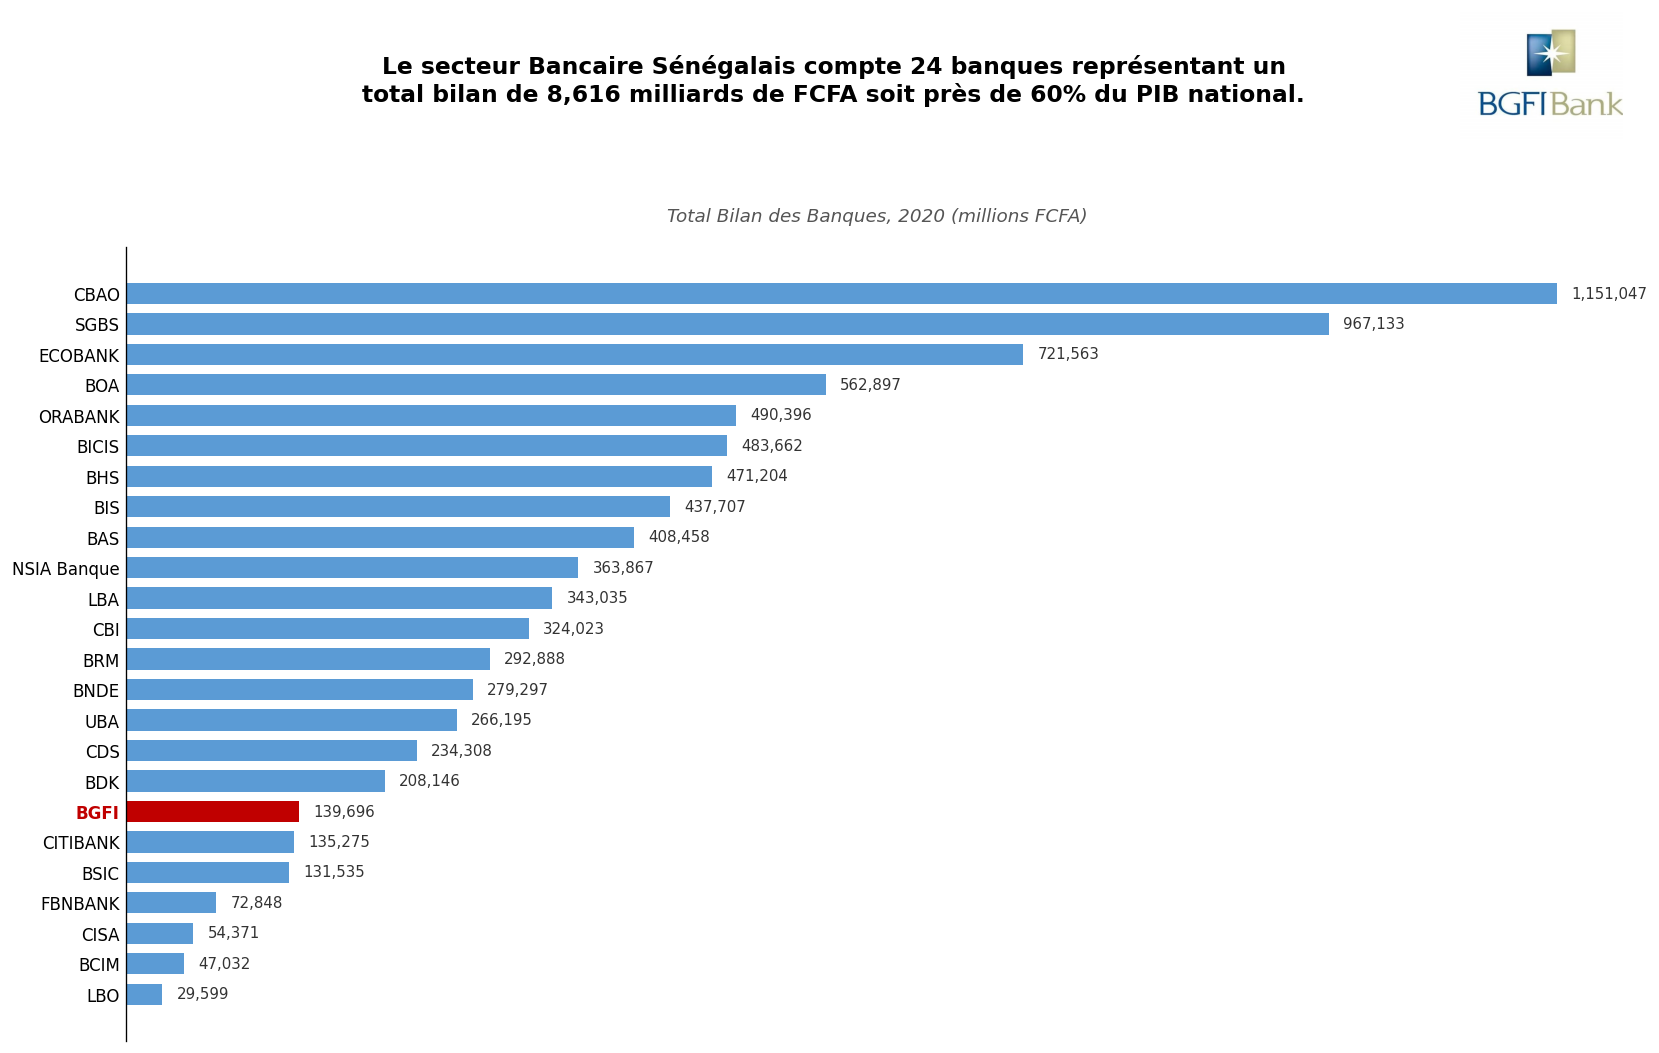

In [37]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # OBLIGATOIRE pour les serveurs/nbconvert
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
# --- AJOUT DE IMAGE ICI ---
from IPython.display import display, Image 

warnings.filterwarnings('ignore')

# ── Paramètres ────────────────────────────────────────────────────
TARGET_BANK   = 'BGFI'
ANNEE_DEBUT   = 2015
ANNEE_FIN     = 2020
C_BGFI        = '#c00000'   # rouge BGFI
C_AUTRE       = 'lightgray' # gris clair
C_BARRE       = '#5b9bd5'   # bleu

# ── Chargement ───────────────────────────────────────────────────
# Note : Utilise un chemin relatif si possible pour le serveur
path_data = r"C:\Users\user\Documents\Data Ingenieur2\Projet_banque\Data\BASE_SENEGAL2.xlsx"

try:
    df = pd.read_excel(path_data, engine='openpyxl')
    df.columns = df.columns.str.strip()
   
except Exception as e:
    print(f"❌ Erreur de lecture : {e}")

# ── Tables de référence ───────────────────────────────────────────
df_2020 = df[df['ANNEE'] == ANNEE_FIN].copy()
total_bilan_2020 = df_2020['BILAN'].sum()

# ═══════════════════════════════════════════════════════════════════════════
# 1-2 TOTAL BILAN DES BANQUES — 2020
# ═══════════════════════════════════════════════════════════════════════════

# Préparation
d_plot = df_2020.sort_values('BILAN', ascending=True)
nb_banques = len(d_plot)
total_mds = round(total_bilan_2020 / 1_000, 0)
couleurs = [C_BGFI if s == TARGET_BANK else C_BARRE for s in d_plot['Sigle']]

# Création
fig, ax = plt.subplots(figsize=(14, 9), facecolor='white')
ax.set_facecolor('white')

bars = ax.barh(d_plot['Sigle'], d_plot['BILAN'], color=couleurs, height=0.7)

# Valeurs au bout des barres
max_val = d_plot['BILAN'].max()
for bar in bars:
    width = bar.get_width()
    ax.text(width + (max_val * 0.01), bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontsize=9, color='#333333')

# Style BGFI
for label in ax.get_yticklabels():
    if label.get_text() == TARGET_BANK:
        label.set_fontweight('bold')
        label.set_color(C_BGFI)

plt.suptitle(f'Le secteur Bancaire Sénégalais compte {nb_banques} banques représentant un\ntotal bilan de {total_mds:,.0f} milliards de FCFA soit près de 60% du PIB national.',
             fontsize=14, fontweight='bold', x=0.5, y=0.96)

ax.set_title(f'Total Bilan des Banques, {ANNEE_FIN} (millions FCFA)', 
             fontsize=11, style='italic', color='#555555', pad=15)

# Nettoyage
ax.spines[['top','right','bottom']].set_visible(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='y', length=0)
ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.90])

# ── 🔥 SOLUTION POUR L'AFFICHAGE DANS LE DOWNLOAD 🔥 ──
# 1. On enregistre l'image physiquement
temp_img = 'temp_graph_1.png'
plt.savefig(temp_img, dpi=120, bbox_inches='tight')
plt.close(fig) # On ferme la figure pour libérer la mémoire

# 2. On affiche le FICHIER IMAGE (c'est ce qui force l'inclusion dans le HTML/PDF)
display(Image(filename=temp_img))

---
## 1-2 Total Bilan des Banques — 2020

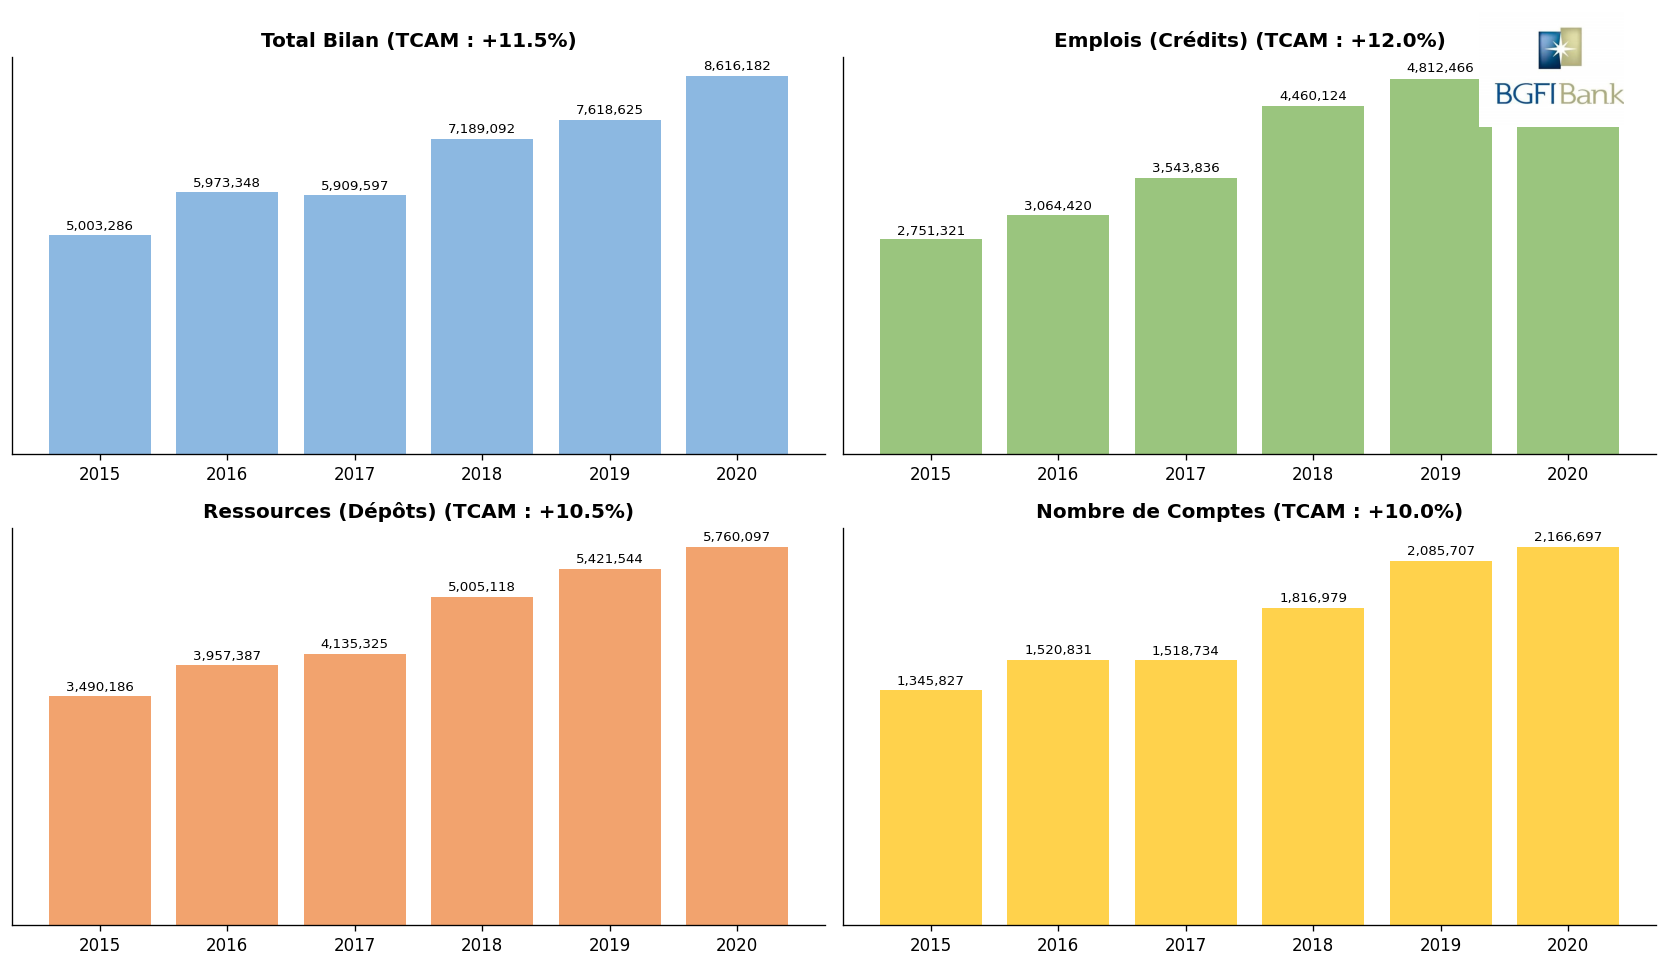

In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-3 UN MARCHÉ EN CROISSANCE — ÉVOLUTION 2015–2020
# ═══════════════════════════════════════════════════════════════════════════

# Redéfinition locale pour éviter le NameError
def calcul_tcam(v0, v1, n):
    try:
        if v0 <= 0 or pd.isna(v0) or pd.isna(v1) or n <= 0: return 0.0
        return round(((v1 / v0) ** (1/n) - 1) * 100, 1)
    except: return 0.0

# Préparation des données agrégées
evolution_marche = df.groupby('ANNEE')[['BILAN', 'EMPLOI', 'RESSOURCES', 'COMPTE']].sum().reset_index()

fig, axs = plt.subplots(2, 2, figsize=(14, 8), facecolor='white')
metrics = [
    ('BILAN', 'Total Bilan', '#5b9bd5'),
    ('EMPLOI', 'Emplois (Crédits)', '#70ad47'),
    ('RESSOURCES', 'Ressources (Dépôts)', '#ed7d31'),
    ('COMPTE', 'Nombre de Comptes', '#ffc000')
]

for i, (col, title, color) in enumerate(metrics):
    ax = axs.flat[i]
    
    # Barres
    bars = ax.bar(evolution_marche['ANNEE'].astype(str), evolution_marche[col], color=color, alpha=0.7)
    
    # Calcul TCAM
    v0 = evolution_marche[evolution_marche['ANNEE'] == ANNEE_DEBUT][col].values[0]
    v1 = evolution_marche[evolution_marche['ANNEE'] == ANNEE_FIN][col].values[0]
    t = calcul_tcam(v0, v1, ANNEE_FIN - ANNEE_DEBUT)
    
    # Valeurs sur barres
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + (h*0.01), f'{h:,.0f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(f"{title} (TCAM : +{t}%)", fontweight='bold')
    # Style local pour éviter une autre NameError
    ax.spines[['top','right']].set_visible(False)
    ax.get_yaxis().set_visible(False)
ajouter_logo(fig)
plt.tight_layout()

# Sauvegarde et Affichage
temp_img_2 = 'temp_graph_2.png'
plt.savefig(temp_img_2, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=temp_img_2))

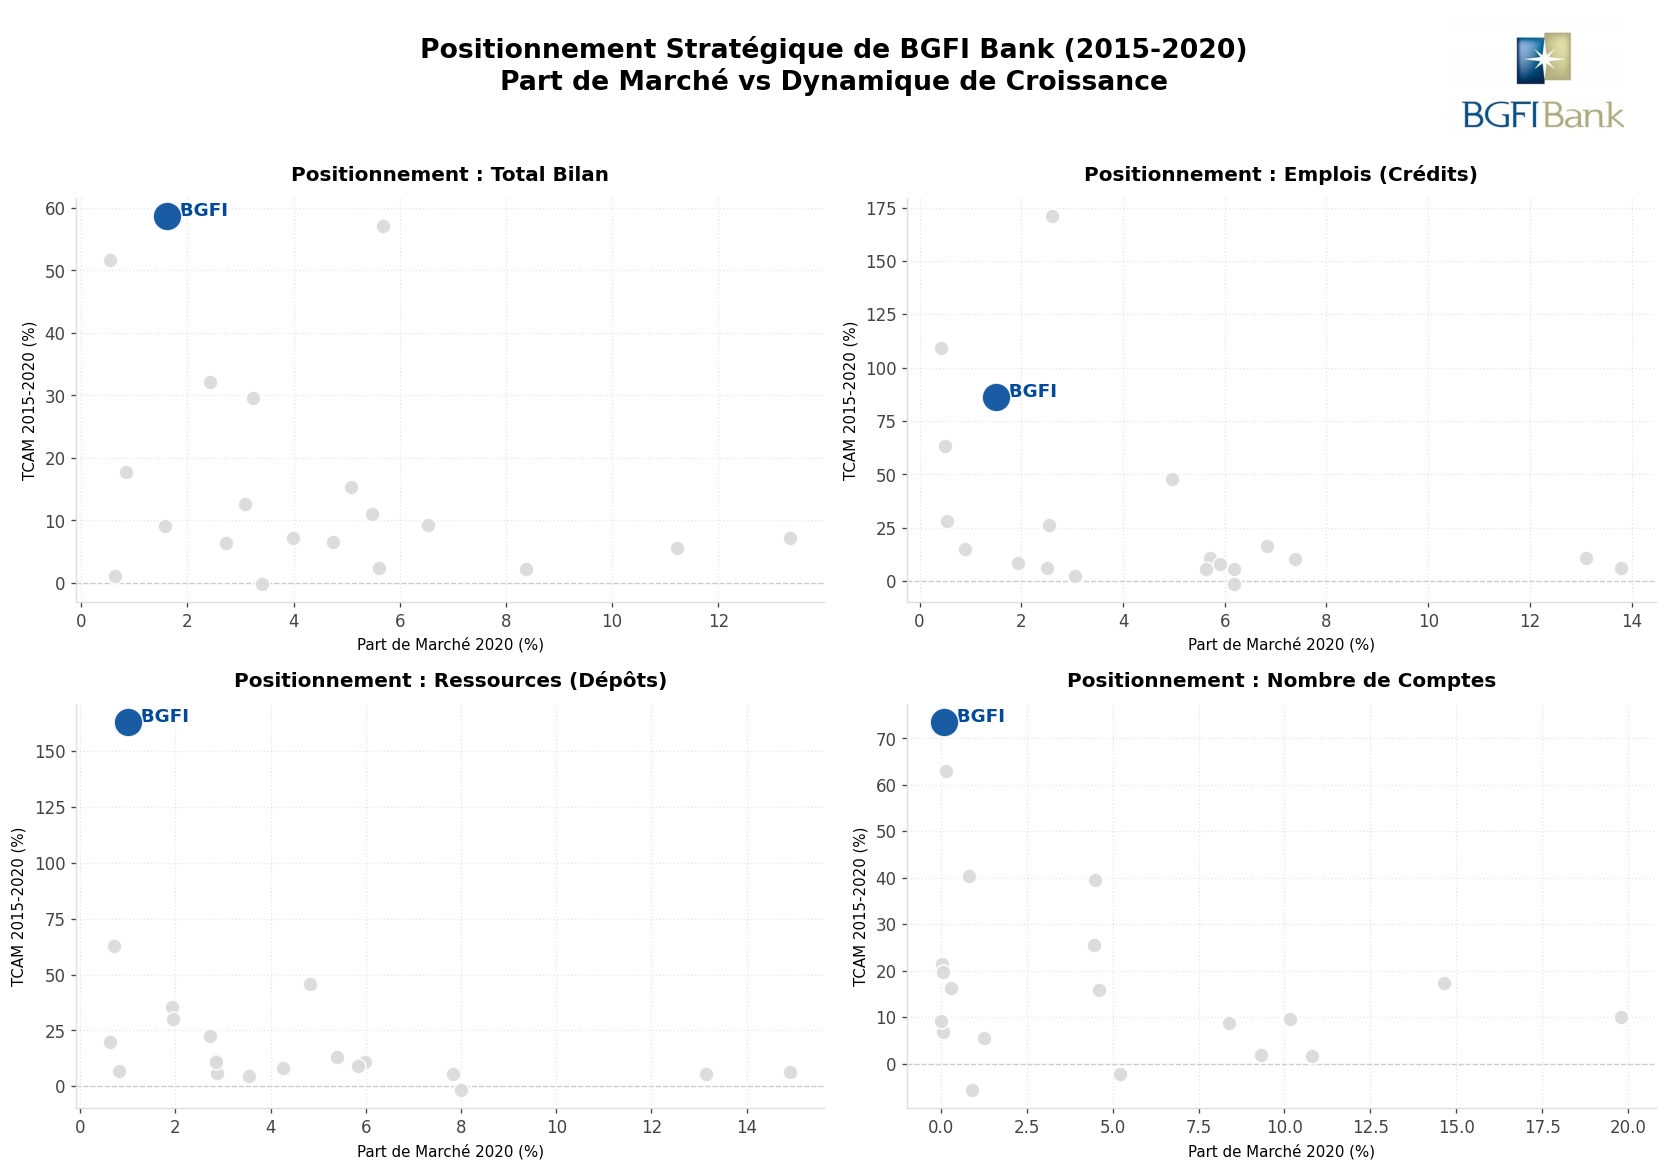

In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-4 POSITIONNEMENT DE BGFI BANK (PART DE MARCHÉ VS TCAM)
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ── Configuration Locale ──────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99' # Bleu Institutionnel pour BGFI
C_MARCHE    = '#d9d9d9' # Gris pour les autres banques
TARGET      = 'BGFI'

def calcul_tcam_local(v0, v1, n):
    try:
        if v0 <= 0 or pd.isna(v0) or pd.isna(v1) or n <= 0: return 0.0
        return round(((v1 / v0) ** (1/n) - 1) * 100, 1)
    except: return 0.0

def style_ax_local(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.tick_params(colors='#444444', length=3)
    ax.set_facecolor('white')

# ── Préparation des données ───────────────────────────────────────────────
metrics = ['BILAN', 'EMPLOI', 'RESSOURCES', 'COMPTE']
titles  = ['Total Bilan', 'Emplois (Crédits)', 'Ressources (Dépôts)', 'Nombre de Comptes']
banques = df['Sigle'].unique()

fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

for i, m in enumerate(metrics):
    ax = axs.flat[i]
    total_m_2020 = df_2020[m].sum()
    
    for b in banques:
        df_b = df[df['Sigle'] == b]
        v_start = df_b[df_b['ANNEE'] == ANNEE_DEBUT][m].values
        v_end   = df_b[df_b['ANNEE'] == ANNEE_FIN][m].values
        
        if len(v_start) > 0 and len(v_end) > 0:
            part_marche = (v_end[0] / total_m_2020) * 100
            croissance  = calcul_tcam_local(v_start[0], v_end[0], 5)
            
            is_target = (str(b).upper() == TARGET)
            
            # Dessin des points
            ax.scatter(part_marche, croissance, 
                       color=C_BGFI_BLUE if is_target else C_MARCHE, 
                       s=300 if is_target else 80,
                       edgecolor='white', linewidth=1,
                       alpha=0.9, zorder=5 if is_target else 3)
            
            # Label pour BGFI
            if is_target:
                ax.annotate(f"  {b}", (part_marche, croissance), 
                            fontweight='bold', color=C_BGFI_BLUE, fontsize=11)

    ax.set_title(f"Positionnement : {titles[i]}", fontweight='bold', pad=10)
    ax.set_xlabel("Part de Marché 2020 (%)", fontsize=9)
    ax.set_ylabel("TCAM 2015-2020 (%)", fontsize=9)
    ax.axhline(0, color='#cccccc', linewidth=0.8, linestyle='--')
    style_ax_local(ax)
    ax.grid(True, linestyle=':', alpha=0.3)

plt.suptitle(f'Positionnement Stratégique de {TARGET} Bank (2015-2020)\nPart de Marché vs Dynamique de Croissance', 
             fontsize=16, fontweight='bold', y=0.98)

ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ── Sauvegarde et Affichage ──
img_pos_path = 'temp_graph_positionnement.png'
plt.savefig(img_pos_path, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=img_pos_path))

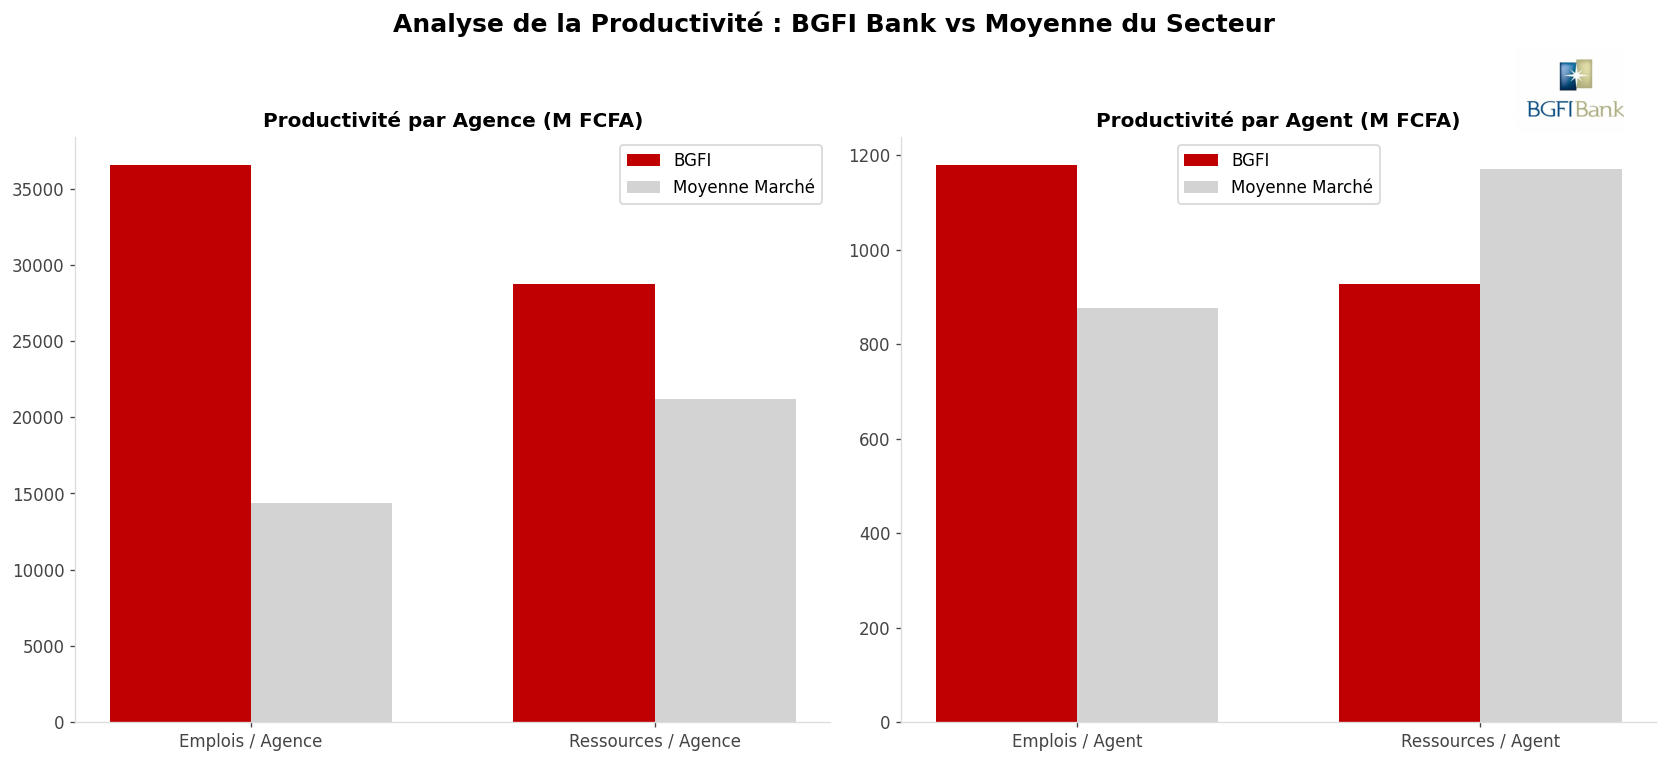

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-5 PRODUCTIVITÉ COMMERCIALE — BGFI VS MARCHÉ (2020)
# ═══════════════════════════════════════════════════════════════════════════

# Fonctions de sécurité pour l'autonomie
def style_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.tick_params(colors='#444444', length=3)
    ax.set_facecolor('white')

# Extraction des données de 2020
row_bgfi = df_2020[df_2020['Sigle'] == TARGET_BANK].iloc[0]

# Calcul des moyennes du marché (en excluant les valeurs aberrantes ou nulles)
moy_empl_ag = (df_2020['EMPLOI'] / df_2020['AGENCE']).replace([np.inf, -np.inf], np.nan).dropna().mean()
moy_ress_ag = (df_2020['RESSOURCES'] / df_2020['AGENCE']).replace([np.inf, -np.inf], np.nan).dropna().mean()

moy_empl_eff = (df_2020['EMPLOI'] / df_2020['EFFECTIF']).replace([np.inf, -np.inf], np.nan).dropna().mean()
moy_ress_eff = (df_2020['RESSOURCES'] / df_2020['EFFECTIF']).replace([np.inf, -np.inf], np.nan).dropna().mean()

# Création des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# --- GRAPHIQUE A : Par Agence ---
labels_ag = ['Emplois / Agence', 'Ressources / Agence']
bgfi_ag   = [row_bgfi['EMPLOI'] / row_bgfi['AGENCE'], row_bgfi['RESSOURCES'] / row_bgfi['AGENCE']]
marche_ag = [moy_empl_ag, moy_ress_ag]

x = np.arange(len(labels_ag))
width = 0.35

ax1.bar(x - width/2, bgfi_ag, width, label=f'{TARGET_BANK}', color=C_BGFI)
ax1.bar(x + width/2, marche_ag, width, label='Moyenne Marché', color=C_AUTRE)

ax1.set_title('Productivité par Agence (M FCFA)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_ag)
ax1.legend()
style_ax(ax1)

# --- GRAPHIQUE B : Par Employé (Effectif) ---
labels_eff = ['Emplois / Agent', 'Ressources / Agent']
bgfi_eff   = [row_bgfi['EMPLOI'] / row_bgfi['EFFECTIF'], row_bgfi['RESSOURCES'] / row_bgfi['EFFECTIF']]
marche_eff = [moy_empl_eff, moy_ress_eff]

ax2.bar(x - width/2, bgfi_eff, width, label=f'{TARGET_BANK}', color=C_BGFI)
ax2.bar(x + width/2, marche_eff, width, label='Moyenne Marché', color=C_AUTRE)

ax2.set_title('Productivité par Agent (M FCFA)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_eff)
ax2.legend()
style_ax(ax2)



plt.suptitle(f'Analyse de la Productivité : {TARGET_BANK} Bank vs Moyenne du Secteur', 
             fontsize=15, fontweight='bold', y=1.05)

ajouter_logo(fig)

plt.tight_layout()

# ── AFFICHAGE SÉCURISÉ ──
temp_img_4 = 'temp_graph_4.png'
plt.savefig(temp_img_4, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=temp_img_4))

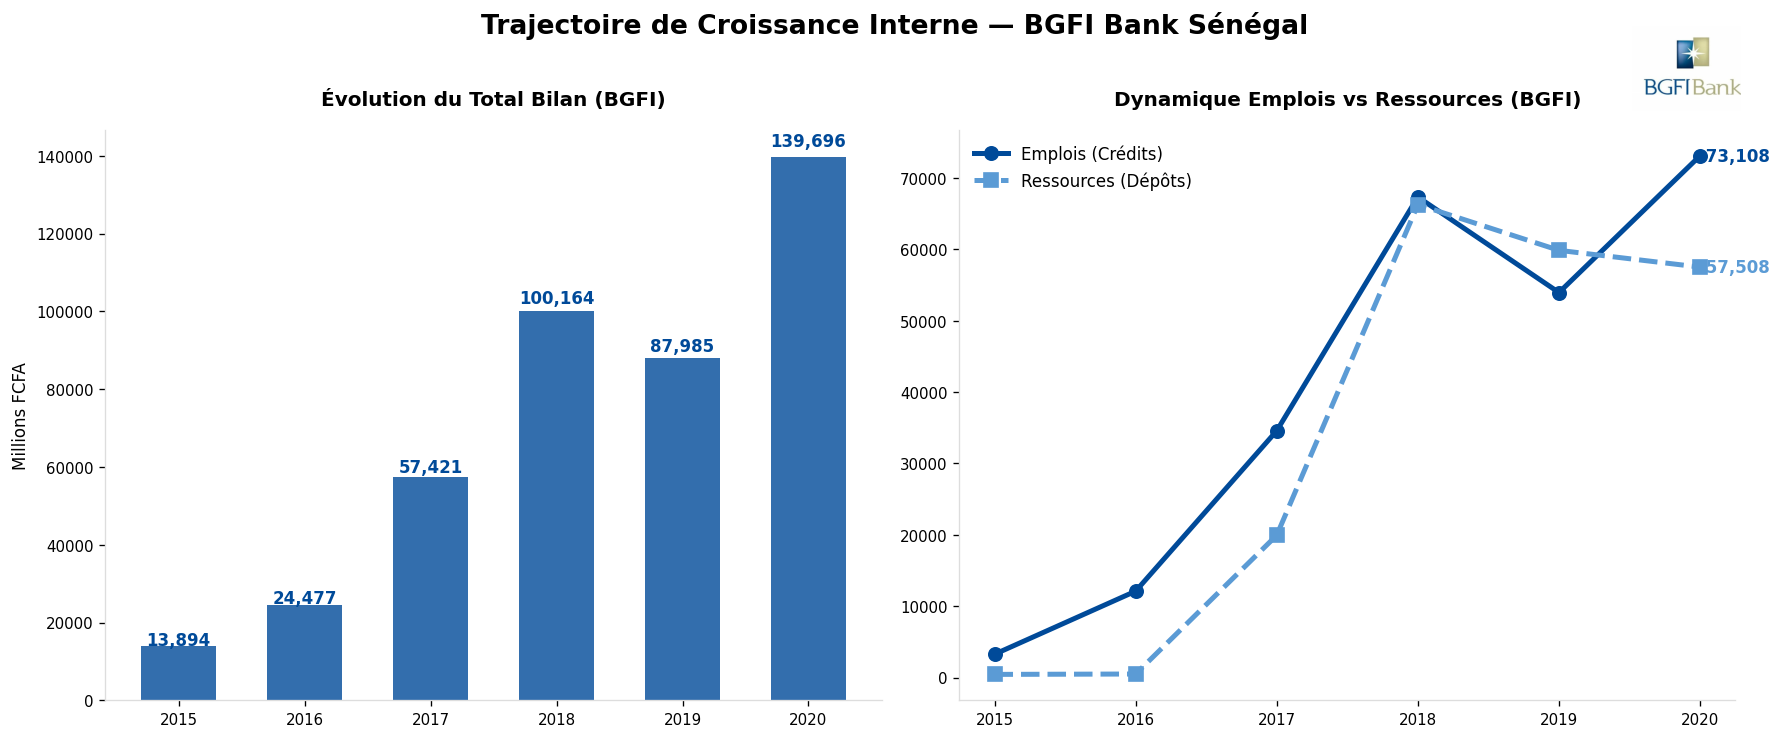

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-5 ÉVOLUTION DE BGFI BANK — INDICATEURS BILANCIELS (2015–2020)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image

# ── Configuration Locale ──────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99' # Ton bleu institutionnel
C_GRIS_FOND = '#f8f9fa'

def style_ax_evol(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', labelsize=9)

# ── Préparation des données BGFI ──────────────────────────────────────────
# On s'assure d'avoir bien filtré sur BGFI uniquement
df_bgfi_evol = df[df['Sigle'] == TARGET_BANK].sort_values('ANNEE')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')

# --- Graphique A : Évolution du Total Bilan (Barres) ---
ax1.bar(df_bgfi_evol['ANNEE'].astype(str), df_bgfi_evol['BILAN'], 
        color=C_BGFI_BLUE, alpha=0.8, width=0.6)

# Ajout des valeurs au-dessus des barres
for i, val in enumerate(df_bgfi_evol['BILAN']):
    ax1.text(i, val + (val*0.02), f'{val:,.0f}', ha='center', fontweight='bold', color=C_BGFI_BLUE)

ax1.set_title(f'Évolution du Total Bilan ({TARGET_BANK})', fontweight='bold', pad=15)
ax1.set_ylabel('Millions FCFA')
style_ax_evol(ax1)

# --- Graphique B : Emplois vs Ressources (Lignes) ---
ax2.plot(df_bgfi_evol['ANNEE'].astype(str), df_bgfi_evol['EMPLOI'], 
         marker='o', markersize=8, linewidth=3, color=C_BGFI_BLUE, label='Emplois (Crédits)')
ax2.plot(df_bgfi_evol['ANNEE'].astype(str), df_bgfi_evol['RESSOURCES'], 
         marker='s', markersize=8, linewidth=3, color='#5b9bd5', label='Ressources (Dépôts)', linestyle='--')

# Valeurs finales en 2020
last_emp = df_bgfi_evol['EMPLOI'].iloc[-1]
last_res = df_bgfi_evol['RESSOURCES'].iloc[-1]
ax2.text(5, last_emp, f' {last_emp:,.0f}', va='center', fontweight='bold', color=C_BGFI_BLUE)
ax2.text(5, last_res, f' {last_res:,.0f}', va='center', fontweight='bold', color='#5b9bd5')

ax2.set_title(f'Dynamique Emplois vs Ressources ({TARGET_BANK})', fontweight='bold', pad=15)
ax2.legend(frameon=False)
style_ax_evol(ax2)



plt.suptitle(f'Trajectoire de Croissance Interne — {TARGET_BANK} Bank Sénégal', 
             fontsize=16, fontweight='bold', y=1.02)

ajouter_logo(fig)

plt.tight_layout()

# ── Sauvegarde et Affichage ──
img_evol_path = 'temp_graph_evol_bgfi.png'
plt.savefig(img_evol_path, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=img_evol_path))

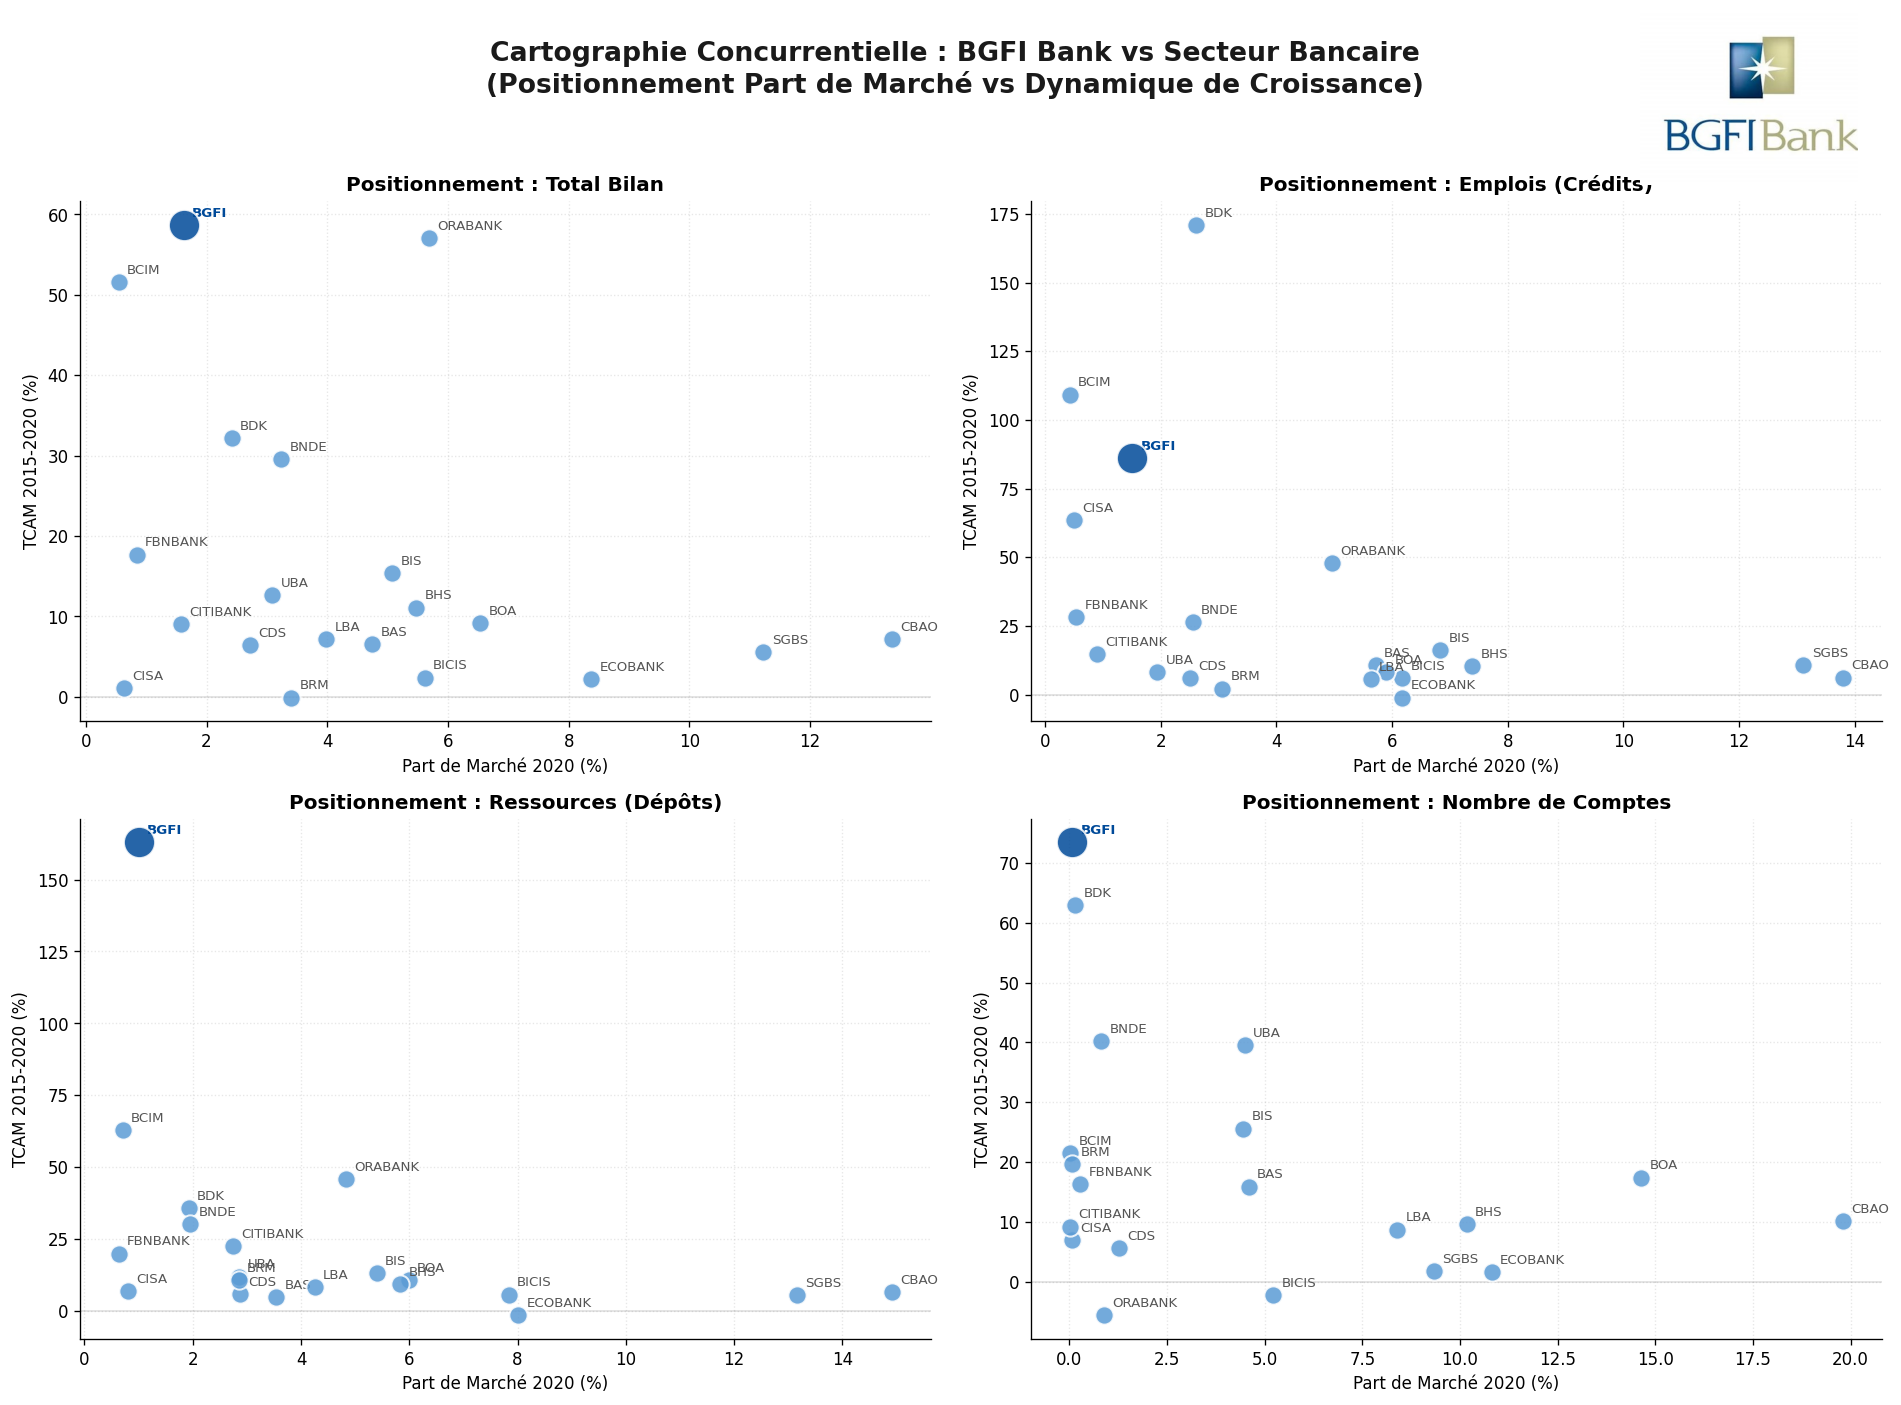

In [42]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-4 POSITIONNEMENT DÉTAILLÉ — BGFI VS TOUTES LES BANQUES (2015–2020)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image
import matplotlib.pyplot as plt

# ── Configuration Visuelle ────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99'  # Bleu Institutionnel BGFI
C_OTHERS    = '#5b9bd5'  # Bleu clair pour les autres banques (visibles)
TARGET      = 'BGFI'

def calcul_tcam_autonome(v0, v1, n):
    try:
        if v0 <= 0 or pd.isna(v0) or pd.isna(v1) or n <= 0: return 0.0
        return round(((v1 / v0) ** (1/n) - 1) * 100, 1)
    except: return 0.0

# ── Préparation des indicateurs ───────────────────────────────────────────
metrics = ['BILAN', 'EMPLOI', 'RESSOURCES', 'COMPTE']
titles  = ['Total Bilan', 'Emplois (Crédits)', 'Ressources (Dépôts)', 'Nombre de Comptes']
all_banks = df['Sigle'].unique()

fig, axs = plt.subplots(2, 2, figsize=(16, 12), facecolor='white')

for i, m in enumerate(metrics):
    ax = axs.flat[i]
    total_m_2020 = df_2020[m].sum()
    
    # On trace d'abord toutes les autres banques
    for b in all_banks:
        df_b = df[df['Sigle'] == b].sort_values('ANNEE')
        v_start = df_b[df_b['ANNEE'] == ANNEE_DEBUT][m].values
        v_end   = df_b[df_b['ANNEE'] == ANNEE_FIN][m].values
        
        if len(v_start) > 0 and len(v_end) > 0:
            ms = (v_end[0] / total_m_2020) * 100
            growth = calcul_tcam_autonome(v_start[0], v_end[0], 5)
            
            is_bgfi = (str(b).upper() == TARGET)
            
            # Affichage du point
            ax.scatter(ms, growth, 
                       color=C_BGFI_BLUE if is_bgfi else C_OTHERS,
                       s=350 if is_bgfi else 120,
                       edgecolor='white', linewidth=1.2,
                       alpha=0.85, zorder=5 if is_bgfi else 3)
            
            # Affichage des noms pour TOUTES les banques
            ax.annotate(f"{b}", (ms, growth), 
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8, 
                        fontweight='bold' if is_bgfi else 'normal',
                        color=C_BGFI_BLUE if is_bgfi else '#555555')

    # Lignes moyennes de marché (Médianes)
    ax.axhline(0, color='#666666', linewidth=1, linestyle='-', alpha=0.2)
    ax.set_title(f"Positionnement : {titles[i]}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Part de Marché 2020 (%)", fontsize=10)
    ax.set_ylabel("TCAM 2015-2020 (%)", fontsize=10)
    
    # Style
    ax.spines[['top','right']].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.3)

# Titre général
plt.suptitle(f'Cartographie Concurrentielle : {TARGET} Bank vs Secteur Bancaire\n(Positionnement Part de Marché vs Dynamique de Croissance)', 
             fontsize=16, fontweight='bold', y=0.98, color='#1a1a1a')

ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ── Sauvegarde et Rendu ──
img_final_pos = 'pos_complet_bgfi_bleu.png'
plt.savefig(img_final_pos, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=img_final_pos))

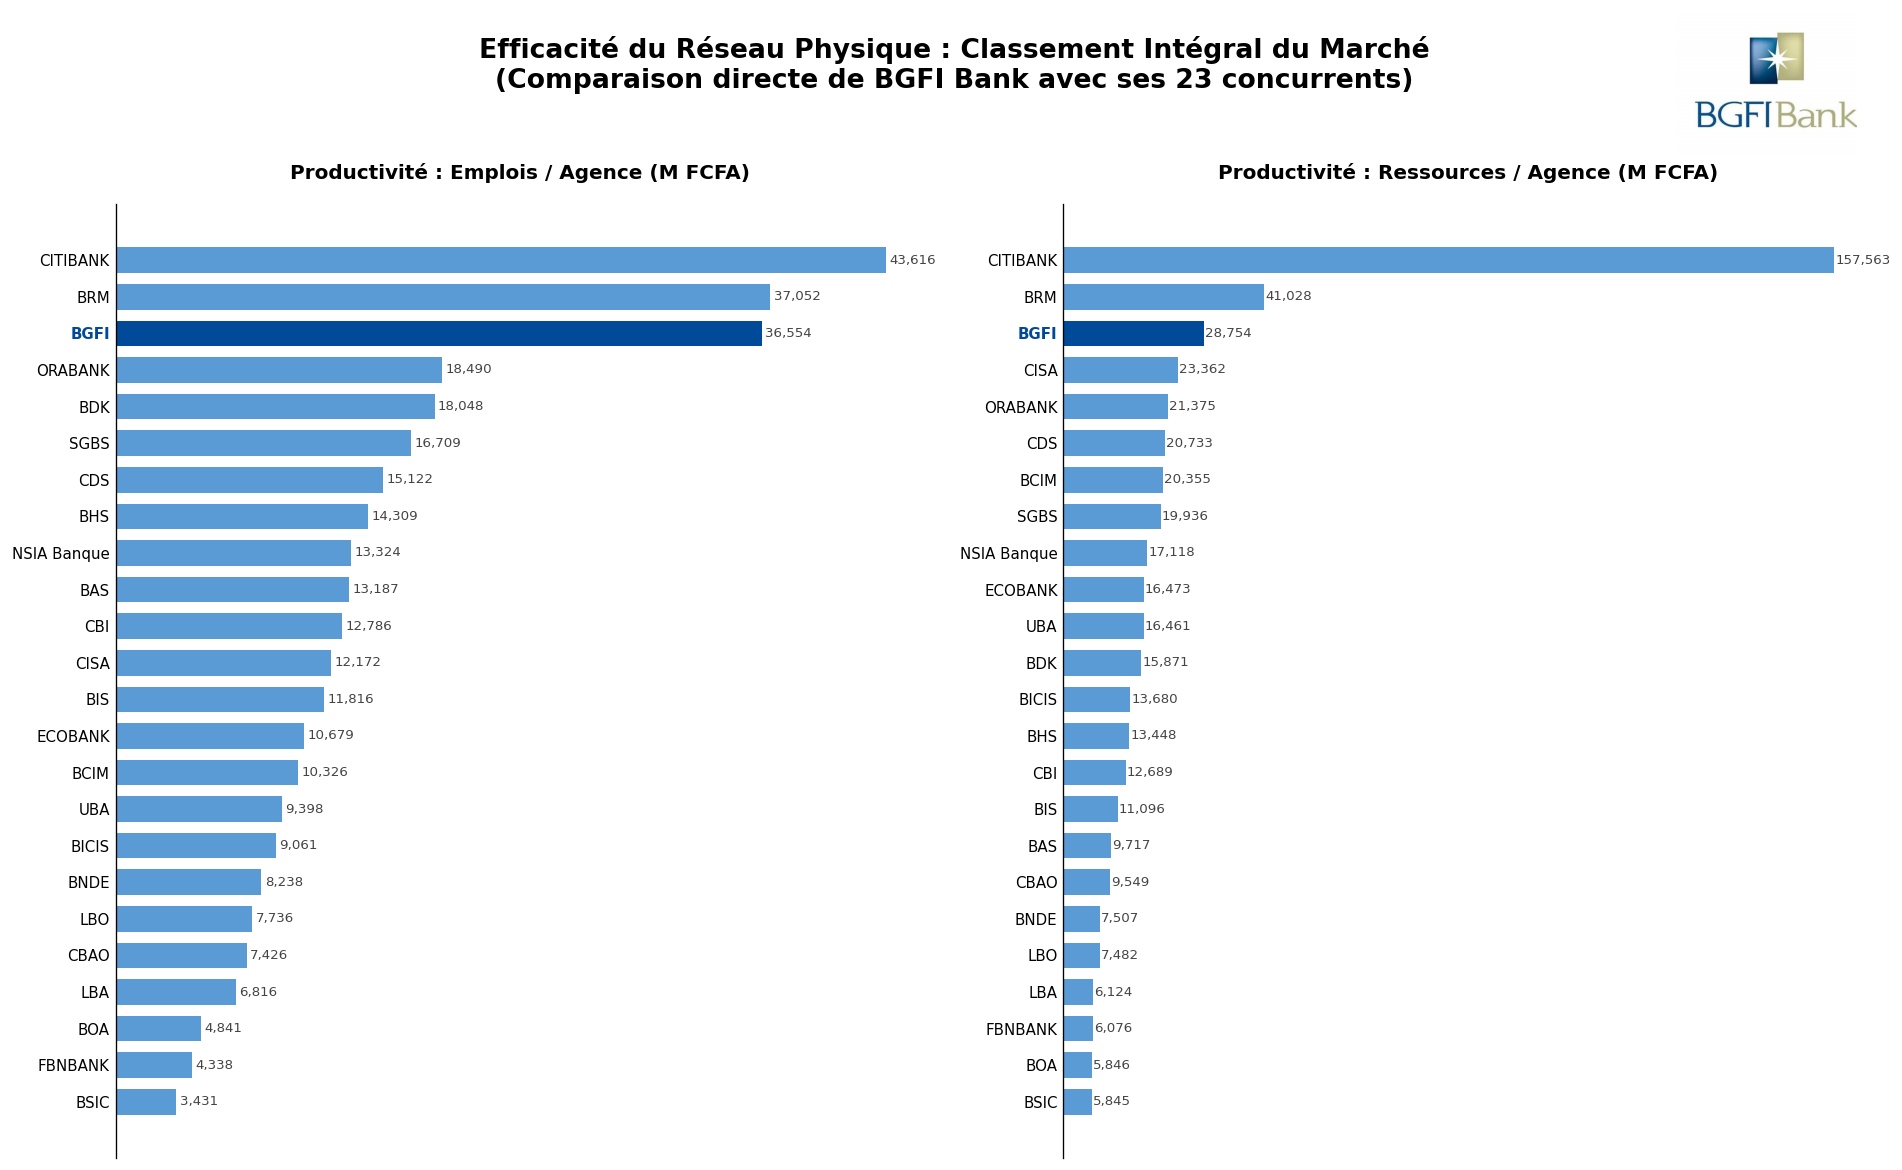

In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-6 RANKING COMPLET DE PRODUCTIVITÉ — TOUTES LES BANQUES (2020)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image
import matplotlib.pyplot as plt

# ── Configuration Visuelle ────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99' 
C_OTHERS    = '#5b9bd5'
TARGET      = 'BGFI'

def style_ax_rank(ax):
    ax.spines[['top','right','bottom']].set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=9)
    ax.set_facecolor('white')

# ── Préparation des ratios ───────────────────────────────────────────────
# On calcule les ratios pour chaque banque en 2020
df_prod = df_2020.copy()
df_prod['EMP_AG'] = df_prod['EMPLOI'] / df_prod['AGENCE']
df_prod['RES_AG'] = df_prod['RESSOURCES'] / df_prod['AGENCE']

# On remplace les infinis (si agences = 0) par 0
df_prod = df_prod.replace([np.inf, -np.inf], 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), facecolor='white')

# --- Graphique 1 : Emplois par Agence (Prêts accordés) ---
d1 = df_prod.sort_values('EMP_AG', ascending=True)
colors1 = [C_BGFI_BLUE if str(s).upper() == TARGET else C_OTHERS for s in d1['Sigle']]
bars1 = ax1.barh(d1['Sigle'], d1['EMP_AG'], color=colors1, height=0.7)

for bar in bars1:
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():,.0f}', va='center', fontsize=8, color='#444444')

ax1.set_title('Productivité : Emplois / Agence (M FCFA)', fontweight='bold', pad=15)
style_ax_rank(ax1)

# --- Graphique 2 : Ressources par Agence (Dépôts collectés) ---
d2 = df_prod.sort_values('RES_AG', ascending=True)
colors2 = [C_BGFI_BLUE if str(s).upper() == TARGET else C_OTHERS for s in d2['Sigle']]
bars2 = ax2.barh(d2['Sigle'], d2['RES_AG'], color=colors2, height=0.7)

for bar in bars2:
    ax2.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():,.0f}', va='center', fontsize=8, color='#444444')

ax2.set_title('Productivité : Ressources / Agence (M FCFA)', fontweight='bold', pad=15)
style_ax_rank(ax2)

# Surlignage de BGFI sur l'axe Y
for ax in [ax1, ax2]:
    for label in ax.get_yticklabels():
        if TARGET in label.get_text().upper():
            label.set_fontweight('bold')
            label.set_color(C_BGFI_BLUE)



plt.suptitle(f'Efficacité du Réseau Physique : Classement Intégral du Marché\n(Comparaison directe de {TARGET} Bank avec ses 23 concurrents)', 
             fontsize=16, fontweight='bold', y=0.98)

ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ── Sauvegarde et Rendu ──
img_prod_all = 'prod_all_banks_bgfi.png'
plt.savefig(img_prod_all, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=img_prod_all))

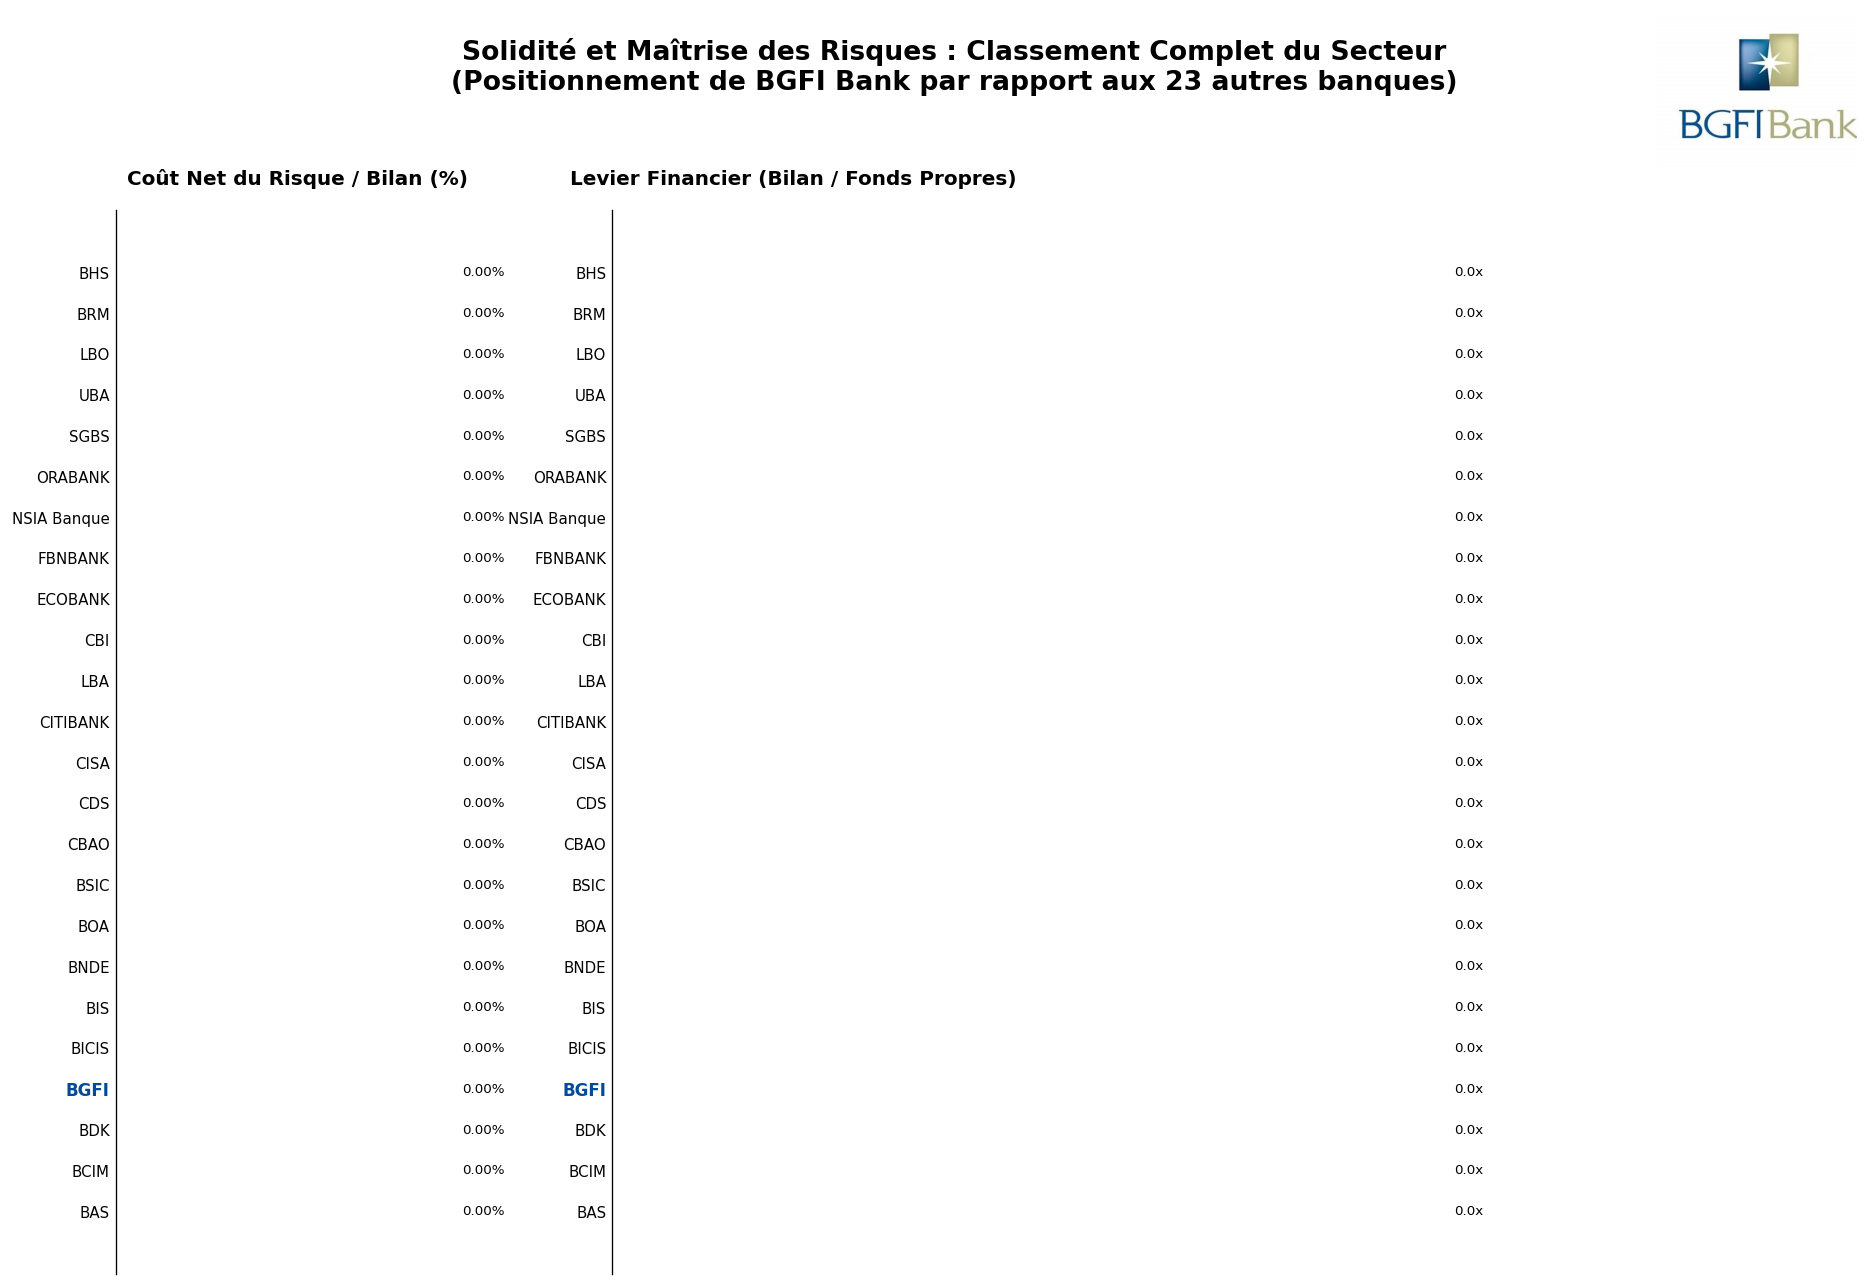

In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-8 RANKING COMPLET RISQUE & LEVIER — TOUTES LES BANQUES (2020)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image
import matplotlib.pyplot as plt

# ── Configuration Visuelle ────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99' # Bleu Institutionnel
C_OTHERS    = '#5b9bd5' # Bleu clair
TARGET      = 'BGFI'

def style_ax_clean(ax):
    ax.spines[['top','right','bottom']].set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=9)
    ax.set_facecolor('white')

# ── Préparation des ratios ───────────────────────────────────────────────
df_risk = df_2020.copy()

# 1. Coût du Risque (% du Bilan)
df_risk['RISQUE_RATIO'] = (df_risk['COÛT.DU.RISQUE'] / df_risk['BILAN']) * 100

# 2. Levier Financier (Bilan / Fonds Propres)
df_risk['LEVIER'] = df_risk['BILAN'] / df_risk['FONDS.PROPRE']

# Nettoyage
df_risk = df_risk.replace([np.inf, -np.inf], 0).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 11), facecolor='white')

# --- Graphique 1 : Coût du Risque (Plus c'est bas, mieux c'est) ---
# Tri décroissant pour voir les moins risqués en bas et les plus risqués en haut
d1 = df_risk.sort_values('RISQUE_RATIO', ascending=True)
colors1 = [C_BGFI_BLUE if str(s).upper() == TARGET else C_OTHERS for s in d1['Sigle']]
bars1 = ax1.barh(d1['Sigle'], d1['RISQUE_RATIO'], color=colors1, height=0.7)

for bar in bars1:
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}%', va='center', fontsize=8)

ax1.set_title('Coût Net du Risque / Bilan (%)', fontweight='bold', pad=15)
style_ax_clean(ax1)

# --- Graphique 2 : Levier Financier (Solidité) ---
d2 = df_risk.sort_values('LEVIER', ascending=True)
colors2 = [C_BGFI_BLUE if str(s).upper() == TARGET else C_OTHERS for s in d2['Sigle']]
bars2 = ax2.barh(d2['Sigle'], d2['LEVIER'], color=colors2, height=0.7)

for bar in bars2:
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}x', va='center', fontsize=8)

ax2.set_title('Levier Financier (Bilan / Fonds Propres)', fontweight='bold', pad=15)
style_ax_clean(ax2)

# Mise en valeur de BGFI sur les axes
for ax in [ax1, ax2]:
    for label in ax.get_yticklabels():
        if TARGET in label.get_text().upper():
            label.set_fontweight('bold')
            label.set_color(C_BGFI_BLUE)
            label.set_fontsize(10)

plt.suptitle(f'Solidité et Maîtrise des Risques : Classement Complet du Secteur\n(Positionnement de {TARGET} Bank par rapport aux 23 autres banques)', 
             fontsize=16, fontweight='bold', y=0.98)

ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


# ── Sauvegarde et Rendu ──
img_risk_all = 'risk_all_banks_bgfi.png'
plt.savefig(img_risk_all, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=img_risk_all))

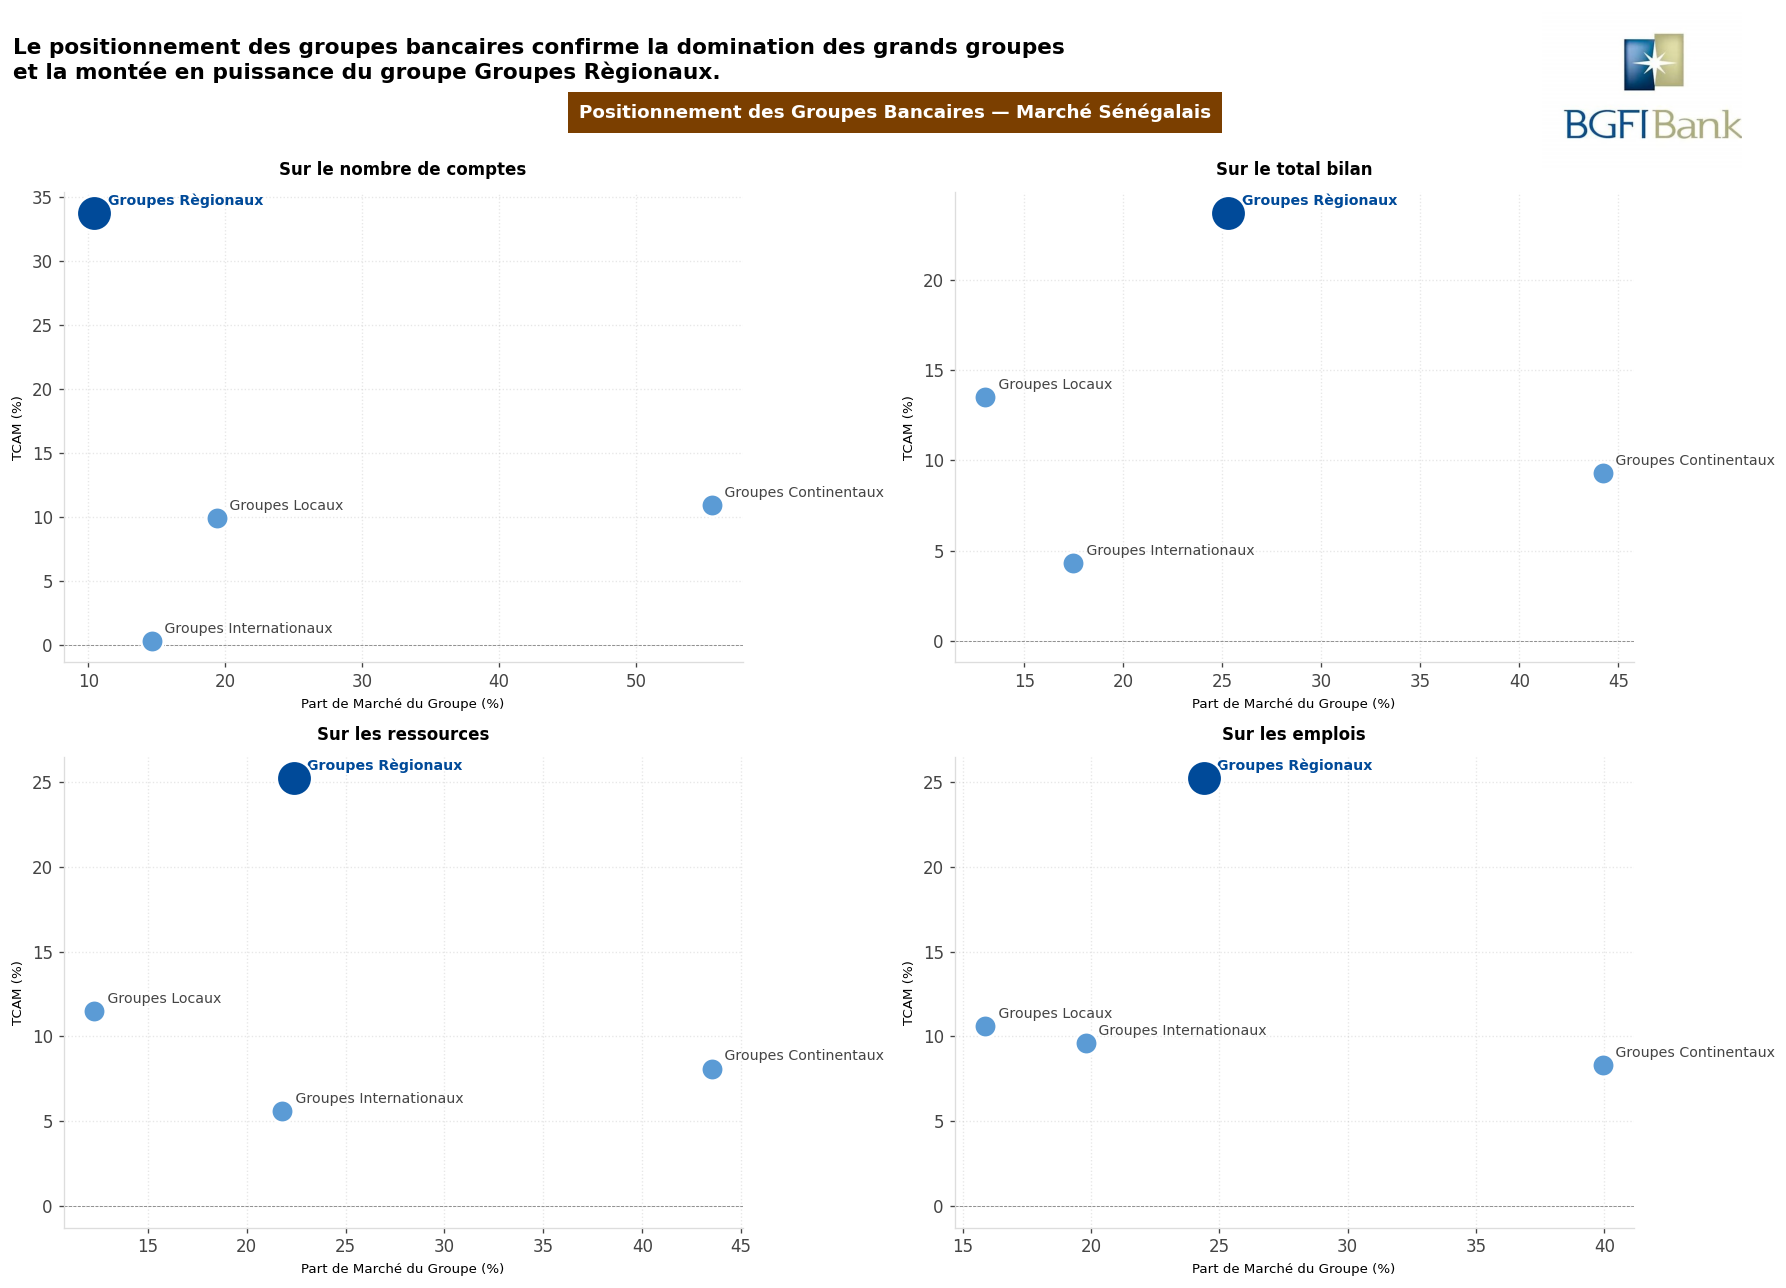

In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-5 POSITIONNEMENT DES GROUPES BANCAIRES (STYLE PPT ORIGINAL)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image

# ── Configuration Visuelle ────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99'  # Ton bleu institutionnel
C_GROUPS    = '#5b9bd5'  # Bleu clair pour les autres groupes
C_BANDEAU   = '#7B3F00'  # Marron original du PPT

# 1. Préparation des données par GROUPE
# On agrège les données : Somme par Groupe et par Année
df_gp = df.groupby(['Goupe_Bancaire', 'ANNEE'])[['BILAN', 'EMPLOI', 'RESSOURCES', 'COMPTE']].sum().reset_index()

# Identification du groupe de BGFI (pour le mettre en bleu)
try:
    GROUPE_BGFI = df[df['Sigle'] == TARGET_BANK]['Goupe_Bancaire'].values[0]
except:
    GROUPE_BGFI = "BGFI"

# ── Fonction de Scatter pour les Groupes ──────────────────────────────────
def scatter_groupes(ax, titre, metric):
    # Total marché 2020 pour la part de marché
    total_m_2020 = df_gp[df_gp['ANNEE'] == ANNEE_FIN][metric].sum()
    groupes_uniques = df_gp['Goupe_Bancaire'].unique()
    
    for gp in groupes_uniques:
        d_g = df_gp[df_gp['Goupe_Bancaire'] == gp].sort_values('ANNEE')
        
        v_start = d_g[d_g['ANNEE'] == ANNEE_DEBUT][metric].values
        v_end   = d_g[d_g['ANNEE'] == ANNEE_FIN][metric].values
        
        if len(v_start) > 0 and len(v_end) > 0:
            ms = (v_end[0] / total_m_2020) * 100
            growth = calcul_tcam(v_start[0], v_end[0], 5)
            
            is_bgfi_gp = (gp == GROUPE_BGFI)
            
            # Point du groupe
            ax.scatter(ms, growth, 
                       color=C_BGFI_BLUE if is_bgfi_gp else C_GROUPS,
                       s=450 if is_bgfi_gp else 180,
                       edgecolor='white', linewidth=1.5, zorder=5 if is_bgfi_gp else 3)
            
            # Nom du groupe (Uniquement si part de marché > 1% ou si c'est BGFI pour la lisibilité)
            if ms > 1 or is_bgfi_gp:
                ax.annotate(f" {gp}", (ms, growth), 
                            fontsize=8.5, fontweight='bold' if is_bgfi_gp else 'normal',
                            color=C_BGFI_BLUE if is_bgfi_gp else '#444444',
                            xytext=(5, 5), textcoords='offset points')

    ax.set_title(titre, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel("Part de Marché du Groupe (%)", fontsize=8)
    ax.set_ylabel("TCAM (%)", fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    style_ax(ax)
    ax.grid(True, linestyle=':', alpha=0.3)

# ── Création de la Figure ──────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(15, 11), facecolor='white')

scatter_groupes(axs[0,0], 'Sur le nombre de comptes', 'COMPTE')
scatter_groupes(axs[0,1], 'Sur le total bilan',       'BILAN')
scatter_groupes(axs[1,0], 'Sur les ressources',       'RESSOURCES')
scatter_groupes(axs[1,1], 'Sur les emplois',          'EMPLOI')

# Texte stratégique en haut à gauche
fig.text(0.01, 0.98,
    f'Le positionnement des groupes bancaires confirme la domination des grands groupes\net la montée en puissance du groupe {GROUPE_BGFI}.',
    fontsize=13, fontweight='bold', va='top', color='black')

# BANDEAU MARRON CENTRAL
fig.text(0.5, 0.92,
    f'Positionnement des Groupes Bancaires — Marché Sénégalais',
    ha='center', fontsize=11, fontweight='bold', color='white',
    bbox=dict(boxstyle='square,pad=0.6', facecolor=C_BANDEAU, edgecolor='none'))
ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.90])

# ── Sauvegarde et Affichage ───────────────────────────────────────────────
path_gp = 'pos_groupes_original.png'
plt.savefig(path_gp, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=path_gp))

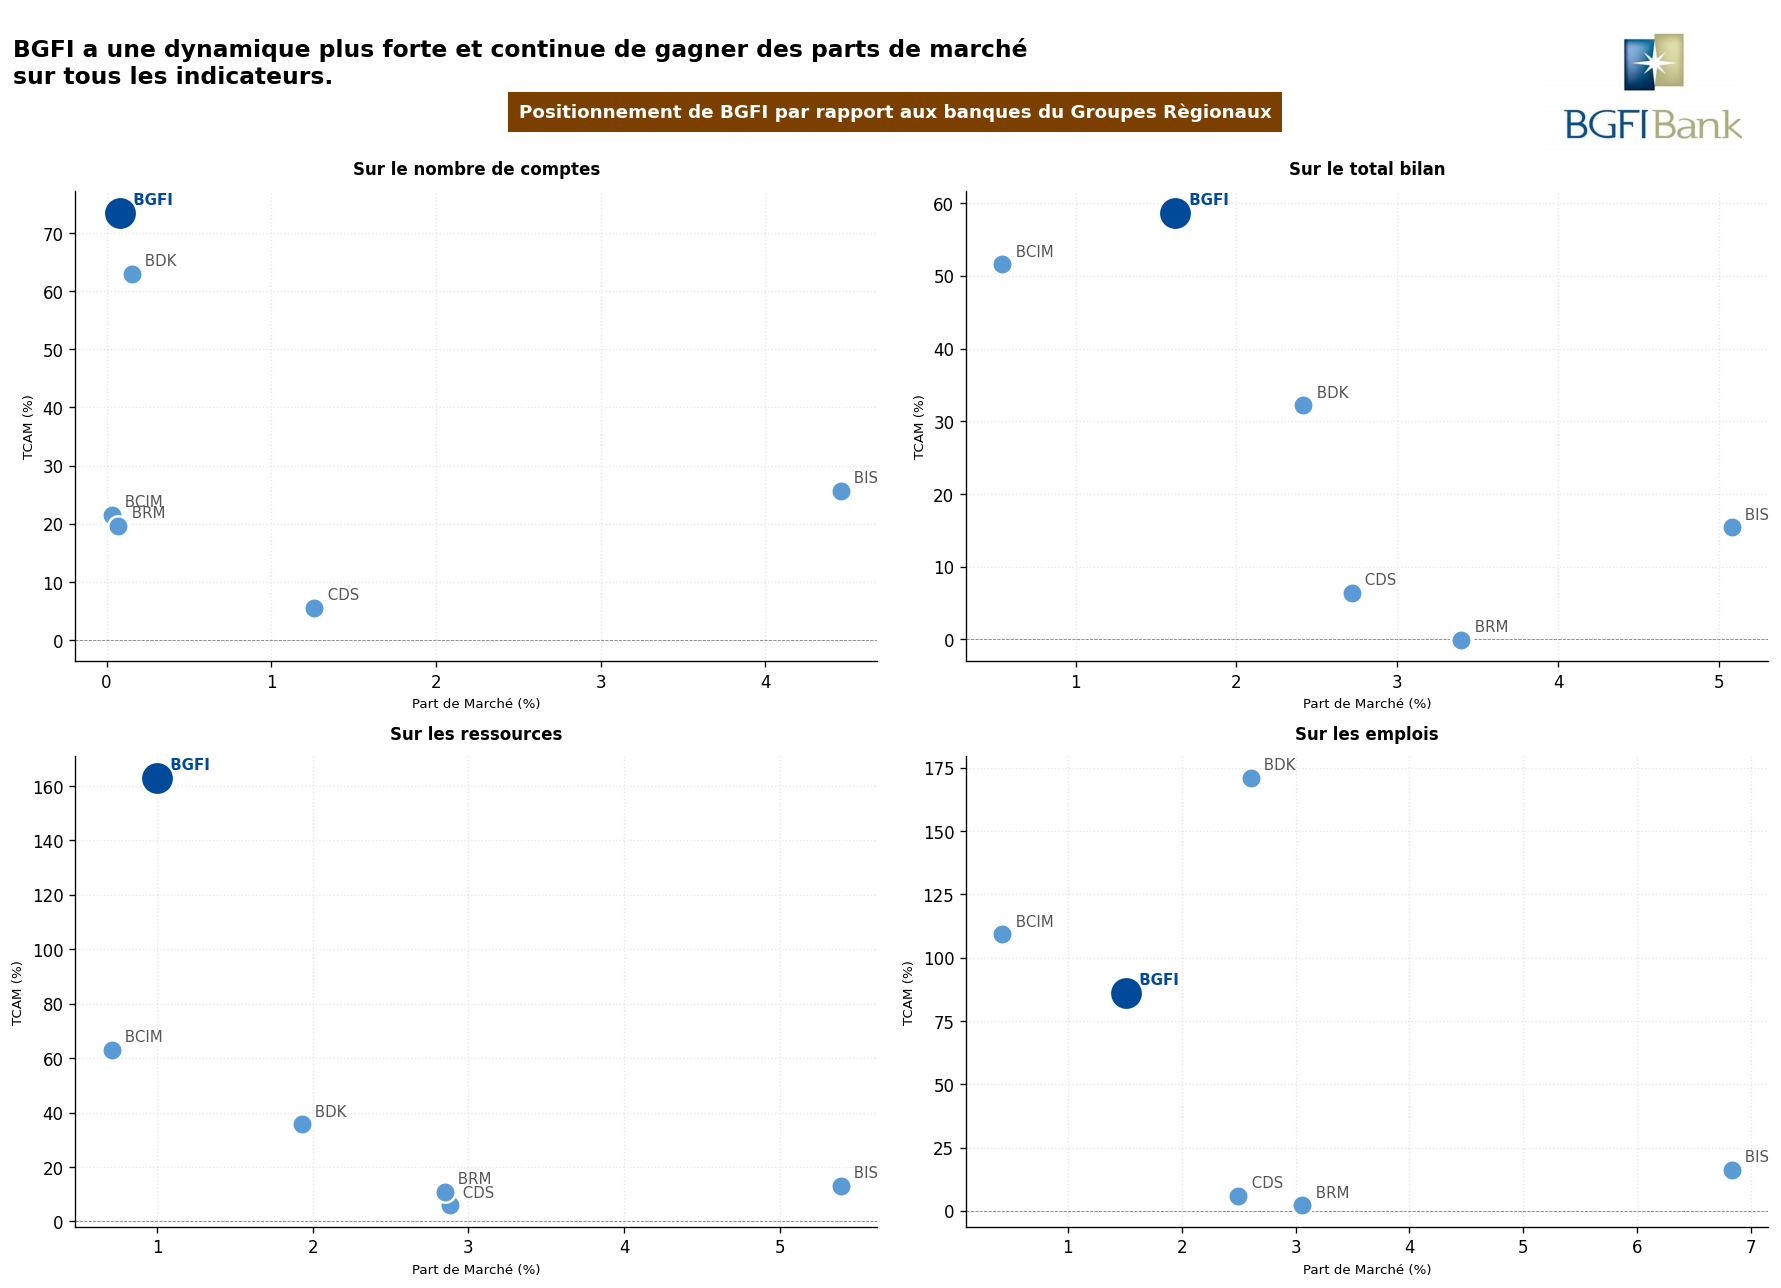

In [46]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-4 POSITIONNEMENT DE BGFI AU SEIN DE SON GROUPE (STYLE PPT ORIGINAL)
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import display, Image

# ── Configuration Visuelle ────────────────────────────────────────────────
C_BGFI_BLUE = '#004a99'  # Ton bleu
C_PEERS     = '#5b9bd5'  # Bleu clair pour les autres banques du groupe
C_BANDEAU   = '#7B3F00'  # Marron original du PPT

# 1. Identification du groupe de BGFI
try:
    GROUPE_TARGET = df_2020[df_2020['Sigle'] == TARGET_BANK]['Goupe_Bancaire'].values[0]
except:
    GROUPE_TARGET = "Même Groupe"

# 2. Filtrage : Uniquement les banques du même groupe
df_groupe = df_2020[df_2020['Goupe_Bancaire'] == GROUPE_TARGET].copy()
banques_groupe = df_groupe['Sigle'].unique()

# ── Fonction de Scatter (Logique Originale) ───────────────────────────────
def scatter_bnk(ax, titre, metric):
    total_m = df_2020[metric].sum()
    
    for b in banques_groupe:
        df_b = df[df['Sigle'] == b].sort_values('ANNEE')
        v_start = df_b[df_b['ANNEE'] == ANNEE_DEBUT][metric].values
        v_end   = df_b[df_b['ANNEE'] == ANNEE_FIN][metric].values
        
        if len(v_start) > 0 and len(v_end) > 0:
            ms = (v_end[0] / total_m) * 100
            growth = calcul_tcam(v_start[0], v_end[0], 5)
            
            is_bgfi = (b == TARGET_BANK)
            
            # Point
            ax.scatter(ms, growth, 
                       color=C_BGFI_BLUE if is_bgfi else C_PEERS,
                       s=400 if is_bgfi else 150,
                       edgecolor='white', linewidth=1.5, zorder=5 if is_bgfi else 3)
            
            # Label lisible (offset pour éviter les chevauchements)
            ax.annotate(f" {b}", (ms, growth), 
                        fontsize=9, fontweight='bold' if is_bgfi else 'normal',
                        color=C_BGFI_BLUE if is_bgfi else '#555555',
                        xytext=(5, 5), textcoords='offset points')

    ax.set_title(titre, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel("Part de Marché (%)", fontsize=8)
    ax.set_ylabel("TCAM (%)", fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(True, linestyle=':', alpha=0.3)
    # Style épuré
    ax.spines[['top','right']].set_visible(False)

# ── Tracé de la Figure ────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(15, 11), facecolor='white')

scatter_bnk(axs[0,0], 'Sur le nombre de comptes', 'COMPTE')
scatter_bnk(axs[0,1], 'Sur le total bilan',       'BILAN')
scatter_bnk(axs[1,0], 'Sur les ressources',       'RESSOURCES')
scatter_bnk(axs[1,1], 'Sur les emplois',          'EMPLOI')

# Titre haut
fig.text(0.01, 0.98,
    f'{TARGET_BANK} a une dynamique plus forte et continue de gagner des parts de marché\nsur tous les indicateurs.',
    fontsize=14, fontweight='bold', va='top', color='black')

# BANDEAU MARRON CENTRAL (Comme demandé)
fig.text(0.5, 0.92,
    f'Positionnement de {TARGET_BANK} par rapport aux banques du {GROUPE_TARGET}',
    ha='center', fontsize=11, fontweight='bold', color='white',
    bbox=dict(boxstyle='square,pad=0.6', facecolor=C_BANDEAU, edgecolor='none'))
ajouter_logo(fig)

plt.tight_layout(rect=[0, 0.03, 1, 0.90])

# ── Sauvegarde et Rendu ───────────────────────────────────────────────────
path_out = 'pos_groupe_original.png'
plt.savefig(path_out, dpi=120, bbox_inches='tight')
plt.close(fig)

display(Image(filename=path_out))

In [48]:
# ═══════════════════════════════════════════════════════════════════════════
# 1-8 SYNTHÈSE GLOBALE — BGFI BANK SÉNÉGAL
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import HTML

# On récupère les dernières valeurs pour le tableau
row = df_2020[df_2020['Sigle'] == TARGET_BANK].iloc[0]
total_m_2020 = df_2020['BILAN'].sum()

# Construction des données
data_final = {
    "Indicateur": ["Total Bilan", "Part de Marché", "ROE (Rentabilité)", "Coût du Risque", "Productivité / Agent"],
    f"{TARGET_BANK}": [
        f"{row['BILAN']:,.0f} M",
        f"{(row['BILAN']/total_m_2020)*100:.2f}%",
        f"{(row['RESULTAT.NET']/row['FONDS.PROPRE'])*100:.1f}%",
        f"{(row['COÛT.DU.RISQUE']/row['BILAN'])*100:.2f}%",
        f"{row['EMPLOI']/row['EFFECTIF']:,.0f} M"
    ],
    "Marché": [
        f"{df_2020['BILAN'].mean():,.0f} M",
        "-",
        f"{(df_2020['RESULTAT.NET']/df_2020['FONDS.PROPRE']).mean()*100:.1f}%",
        f"{(df_2020['COÛT.DU.RISQUE']/df_2020['BILAN']).mean()*100:.2f}%",
        f"{(df_2020['EMPLOI']/df_2020['EFFECTIF']).mean():,.0f} M"
    ],
    "Statut": [" Croissance", " À renforcer", " Performant", " Maîtrisé", "Efficace"]
}
ajouter_logo(fig)
df_final = pd.DataFrame(data_final)

# Génération du HTML stylisé
html_table = df_final.to_html(index=False, classes='table table-striped')

# Ajout de style CSS pour le rendu final
style = """
<style>
    .report-table { font-family: sans-serif; border-collapse: collapse; width: 100%; }
    .report-table td, .report-table th { border: 1px solid #ddd; padding: 12px; text-align: center; }
    .report-table th { background-color: #004a99; color: white; }
    .bgfi-col { font-weight: bold; color: #004a99; }
</style>
"""

print("\n" + "="*50 + "\n  TABLEAU DE SYNTHÈSE STRATÉGIQUE\n" + "="*50)
display(HTML(style + html_table.replace('class="dataframe table table-striped"', 'class="report-table"')))


  TABLEAU DE SYNTHÈSE STRATÉGIQUE


Indicateur,BGFI,Marché,Statut
Total Bilan,"139,696 M","359,008 M",Croissance
Part de Marché,1.62%,-,À renforcer
ROE (Rentabilité),nan%,nan%,Performant
Coût du Risque,nan%,nan%,Maîtrisé
Productivité / Agent,"1,179 M",876 M,Efficace
